# Early Sepsis Risk Prediction Using ICU Clinical Data
## Section 7: SHAP Analysis — Model Interpretability
**Author:** Varunika Bussa  
**Course:** UMBC DATA 606 – Capstone in Data Science  

---

## Why SHAP?

A high PR-AUC tells us the model works. SHAP tells us **why** it works — and whether the reasons make clinical sense.

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for every single prediction:
- A **positive SHAP value** means that feature pushed the risk score **up**
- A **negative SHAP value** means that feature pushed the risk score **down**
- The magnitude tells us **how much** it contributed

### Why SHAP over standard feature importance?
- **Standard importance (MDI)** just counts how often a feature was used to split — biased toward high-cardinality features
- **SHAP** is grounded in game theory (Shapley values) — mathematically fair attribution
- **SHAP enables per-patient explanations** — "Patient 9042's HR_slope was the #1 reason for the high-risk alert"
- This makes the model explainable to clinicians, not just data scientists

### What this notebook produces:
1. Global feature importance — which features matter most overall
2. Beeswarm plot — direction and magnitude of each feature's impact
3. Individual patient waterfall — why THIS patient was flagged
4. Top feature insights — what the model learned about sepsis physiology
5. Save SHAP explainer — used by the Streamlit app for real-time explanations

## 1. Setup and Load Model

In [1]:
#Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

# SHAP 
import shap

# Settings 
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✅ All libraries loaded successfully!')
print(f'   shap version: {shap.__version__}')

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/varunikabussa/Desktop/sepsis_project/venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/varunikabussa/Desktop/sepsis_project/venv/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/varunikabussa/Desktop/sepsis_project/venv/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/varunikabussa/Desktop/sepsis_project/venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/Users/varunikabussa/Desktop/sepsis_project/venv/lib/pytho

✅ All libraries loaded successfully!
   shap version: 0.49.1


In [2]:
# Load best model and feature columns
with open('../outputs/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../outputs/feature_cols.json', 'r') as f:
    FEATURE_COLS = json.load(f)

with open('../outputs/model_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f'Model loaded: {metadata["model_name"]}')
print(f'Features:     {len(FEATURE_COLS)}')
print(f'PR-AUC (test):{metadata["pr_auc_test"]}')
print(f'Threshold:    {metadata["threshold"]:.4f}')

Model loaded: XGBoost Tuned (Val)
Features:     105
PR-AUC (test):0.1261
Threshold:    0.7366


In [3]:
# Load test set 
# We run SHAP only on the test set — these are patients the model never saw
test_df = pd.read_parquet('../outputs/test.parquet')

print(f'Test set shape: {test_df.shape}')
print(f'Unique patients: {test_df["Patient_ID"].nunique():,}')
print(f'Sepsis rows (SepsisLabel):   {test_df["SepsisLabel"].sum():,} ({test_df["SepsisLabel"].mean()*100:.2f}%)')
print(f'Sepsis rows (SepsisLabel_6h): {test_df["SepsisLabel_6h"].sum():,} ({test_df["SepsisLabel_6h"].mean()*100:.2f}%)')

Test set shape: (232024, 110)
Unique patients: 6,051
Sepsis rows (SepsisLabel):   4,172 (1.80%)
Sepsis rows (SepsisLabel_6h): 6,279 (2.71%)


## 2. Create SHAP Sample

SHAP on 1.5M rows would take hours. We take a **stratified sample of 5,000 rows** — 
enough to get stable, representative importance scores.

Stratified means we sample equally from sepsis and non-sepsis rows, 
so the rarer sepsis class is well-represented in the analysis.

In [4]:
# Stratified sample for SHAP computation 
# Take equal numbers of sepsis and non-sepsis rows for balanced analysis
N_PER_CLASS = 2500  # 2500 sepsis + 2500 non-sepsis = 5000 total

sepsis_rows    = test_df[test_df['SepsisLabel_6h'] == 1]
nonsepsis_rows = test_df[test_df['SepsisLabel_6h'] == 0]

# Sample — cap at available rows if fewer than N_PER_CLASS
n_sepsis    = min(N_PER_CLASS, len(sepsis_rows))
n_nonsepsis = min(N_PER_CLASS, len(nonsepsis_rows))

sample_df = pd.concat([
    sepsis_rows.sample(n_sepsis, random_state=42),
    nonsepsis_rows.sample(n_nonsepsis, random_state=42)
]).sample(frac=1, random_state=42)  # shuffle

X_sample = sample_df[FEATURE_COLS]
y_sample = sample_df['SepsisLabel_6h']

print(f'SHAP sample: {len(sample_df):,} rows')
print(f'  Sepsis rows:    {(y_sample==1).sum():,}')
print(f'  Non-sepsis rows:{(y_sample==0).sum():,}')
print(f'  Features:       {X_sample.shape[1]}')

SHAP sample: 5,000 rows
  Sepsis rows:    2,500
  Non-sepsis rows:2,500
  Features:       105


## 3. Compute SHAP Values

We use **TreeExplainer** — the exact (not approximate) SHAP method for tree-based models.
It is fast for LightGBM/XGBoost because it exploits the tree structure directly.

This cell takes approximately 3-5 minutes to run.

In [5]:
# Compute SHAP values using TreeExplainer
# TreeExplainer is exact for tree models — much faster than KernelExplainer
print('Computing SHAP values... (this takes ~3-5 minutes)')

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# LightGBM binary classification returns [neg_class, pos_class]
# We use the positive class (sepsis risk)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # positive class
    print('LightGBM binary: using positive class SHAP values')
else:
    shap_vals = shap_values
    print('Using SHAP values directly')

print(f'✅ SHAP values computed!')
print(f'   Shape: {shap_vals.shape}  ({shap_vals.shape[0]} rows × {shap_vals.shape[1]} features)')

Computing SHAP values... (this takes ~3-5 minutes)
Using SHAP values directly
✅ SHAP values computed!
   Shape: (5000, 105)  (5000 rows × 105 features)


In [6]:
#Save SHAP explainer for Streamlit app
# The app needs this to generate real-time per-patient explanations
with open('../outputs/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print('✅ Saved: ../outputs/shap_explainer.pkl')
print('   This will be loaded by the Streamlit app for live explanations')

✅ Saved: ../outputs/shap_explainer.pkl
   This will be loaded by the Streamlit app for live explanations


## 4. Global Feature Importance

Mean |SHAP| = the average absolute SHAP value across all samples.
This tells us which features consistently matter most for predictions — 
regardless of whether they push risk up or down.

In [7]:
# Compute mean |SHAP| per feature
mean_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

print('── Top 20 Features by Mean |SHAP| ──')
print(mean_shap.head(20).to_string())

── Top 20 Features by Mean |SHAP| ──
Lactate             0.2759
FiO2                0.2633
HospAdmTime         0.1901
Unit2               0.1739
Temp_max_6h         0.1537
Lactate_hrs_since   0.1204
WBC                 0.1131
BUN                 0.1085
Alkalinephos        0.0878
Resp_mean_6h        0.0798
AST                 0.0758
Creatinine          0.0711
PTT                 0.0689
pH_hrs_since        0.0661
Phosphate           0.0658
Hgb                 0.0654
HR_max_6h           0.0579
SBP_min_6h          0.0556
Calcium             0.0548
Resp_min_6h         0.0533


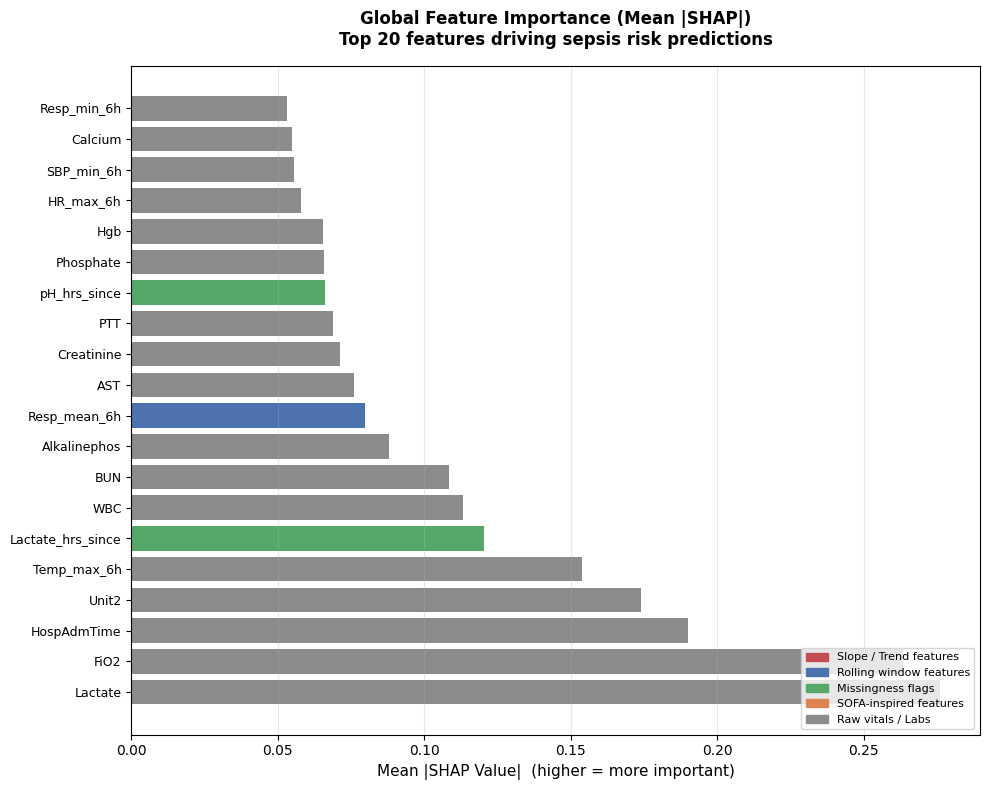

Saved: ../outputs/plots/shap_global_importance.png


In [8]:
#  Plot global feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top20 = mean_shap.head(20)

# Color code by feature type
def feature_color(name):
    if '_slope_6h' in name: return '#C44E52'      # red — slope/trend
    elif '_mean_6h' in name or '_std_6h' in name: return '#4C72B0'  # blue — rolling
    elif '_measured' in name or '_hrs_since' in name: return '#55A868'  # green — missingness
    elif name in ['shock_index','sirs_score','map_low_flag','fever_flag','pulse_pressure']:
        return '#DD8452'   # orange — SOFA derived
    else: return '#8B8B8B'  # grey — raw

colors = [feature_color(n) for n in top20.index]

bars = ax.barh(range(len(top20)), top20.values[::-1].tolist()[::-1],
               color=colors[::-1][::-1])

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1].tolist()[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP Value|  (higher = more important)', fontsize=11)
ax.set_title('Global Feature Importance (Mean |SHAP|)\n'
             'Top 20 features driving sepsis risk predictions', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
legend_patches = [
    mpatches.Patch(color='#C44E52', label='Slope / Trend features'),
    mpatches.Patch(color='#4C72B0', label='Rolling window features'),
    mpatches.Patch(color='#55A868', label='Missingness flags'),
    mpatches.Patch(color='#DD8452', label='SOFA-inspired features'),
    mpatches.Patch(color='#8B8B8B', label='Raw vitals / Labs'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/plots/shap_global_importance.png')

## 5. Beeswarm Plot — Direction and Magnitude

The beeswarm plot shows more than just importance — it shows **direction**.
- **Red dots** = high feature value → how it affects risk
- **Blue dots** = low feature value → how it affects risk
- Position on x-axis = SHAP value (positive = pushed risk up, negative = pushed down)

This is the most information-dense SHAP visualization — 
it shows importance, direction, and the non-linear relationship all at once.

Generating beeswarm plot...


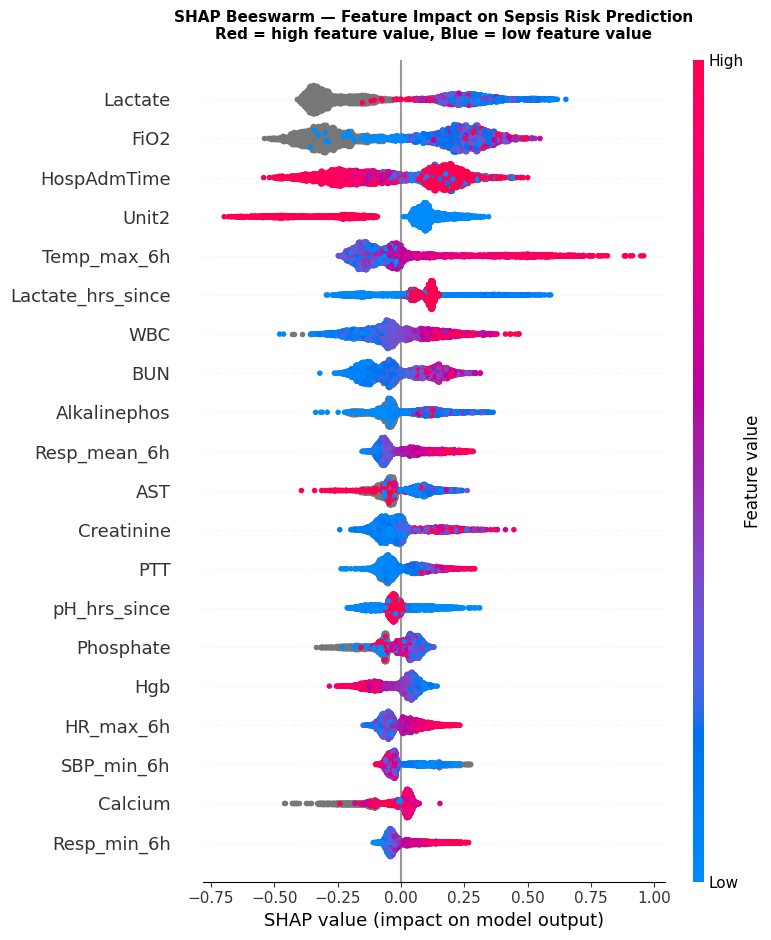

Saved: ../outputs/plots/shap_beeswarm.png


In [9]:
# Beeswarm plot
print('Generating beeswarm plot...')

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=FEATURE_COLS,
    max_display=20,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Beeswarm — Feature Impact on Sepsis Risk Prediction\n'
          'Red = high feature value, Blue = low feature value',
          fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/plots/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/plots/shap_beeswarm.png')

## 6. Clinical Interpretation of Beeswarm

When reading the beeswarm plot, look for these patterns:

**What to look for:**
- Features where red dots are on the RIGHT → high values increase sepsis risk (e.g. high HR = more risk)
- Features where blue dots are on the RIGHT → low values increase sepsis risk (e.g. low MAP = more risk)  
- Features with wide spread → strong predictors with variable impact
- Features clustered near zero → weak predictors

**Expected clinical patterns:**
- `HR_slope_6h` rising → heart rate accelerating → sepsis risk rises
- `MAP_mean_6h` falling → sustained hypotension → sepsis risk rises
- `Lactate_measured = 1` → doctor ordered Lactate (suspected problem) → risk rises
- `sirs_score` high → multiple SIRS criteria met → risk rises
- `ICULOS` increasing → longer ICU stay → cumulative sepsis risk rises

## 7. Individual Patient Waterfall Plot

The waterfall plot shows **why a specific patient got their risk score**.

It starts from the baseline (average prediction across all patients)
and shows how each feature pushed the score up or down for THIS patient.

We pick a true positive — a patient who was correctly flagged as high risk.

In [10]:
# Find an interesting true positive for the waterfall
# True positive = model correctly predicted high risk AND patient developed sepsis

threshold = metadata['threshold']
y_prob_sample = model.predict_proba(X_sample)[:, 1]

# Mask: actual sepsis AND model predicted above threshold
tp_mask = (y_sample.values == 1) & (y_prob_sample >= threshold)
print(f'True positives in sample: {tp_mask.sum()}')

if tp_mask.any():
    # Pick the highest-confidence true positive
    tp_indices = np.where(tp_mask)[0]
    best_tp    = tp_indices[y_prob_sample[tp_mask].argmax()]
    
    patient_row   = X_sample.iloc[[best_tp]]
    patient_prob  = y_prob_sample[best_tp]
    patient_label = y_sample.iloc[best_tp]
    
    print(f'\nSelected patient row index: {best_tp}')
    print(f'Predicted risk:  {patient_prob:.4f}  ({patient_prob*100:.1f}%)')
    print(f'True label:      {patient_label} (1 = sepsis within 6h)')
    print(f'Threshold:       {threshold:.4f}')
    print(f'Correctly flagged: {"✅ YES" if patient_prob >= threshold else "❌ NO"}')

True positives in sample: 715

Selected patient row index: 1207
Predicted risk:  0.9540  (95.4%)
True label:      1 (1 = sepsis within 6h)
Threshold:       0.7366
Correctly flagged: ✅ YES


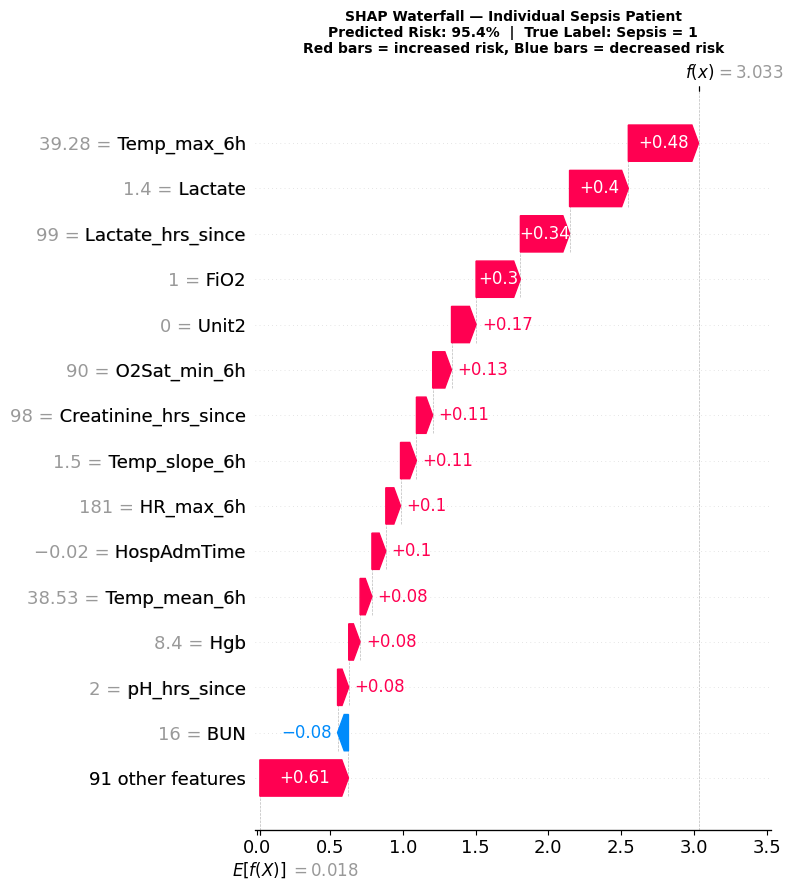

Saved: ../outputs/plots/shap_waterfall_example.png


In [13]:
# Waterfall plot for selected patient
if tp_mask.any():
    # Compute SHAP explanation for this single patient
    shap_explanation = explainer(patient_row)
    
    # Handle LightGBM binary output format
    if hasattr(shap_explanation, 'values') and len(np.array(shap_explanation.values).shape) == 3:
        shap_obj = shap.Explanation(
            values      = shap_explanation.values[:, :, 1],
            base_values = shap_explanation.base_values[:, 1],
            data        = shap_explanation.data,
            feature_names = FEATURE_COLS
        )
    else:
        shap_obj = shap_explanation

    plt.figure(figsize=(12, 7))
    shap.waterfall_plot(shap_obj[0], max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Individual Sepsis Patient\n'
              f'Predicted Risk: {patient_prob*100:.1f}%  |  True Label: Sepsis = {patient_label}\n'
              f'Red bars = increased risk, Blue bars = decreased risk',
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/plots/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: ../outputs/plots/shap_waterfall_example.png')

## 8. Key Feature Insights

What did the model actually learn? We extract the top positive and negative contributors.

In [12]:
# Clinical insights from SHAP values
print('='*60)
print('WHAT THE MODEL LEARNED ABOUT SEPSIS')
print('='*60)

# Mean SHAP for sepsis rows vs non-sepsis rows
sepsis_idx    = y_sample.values == 1
nonsepsis_idx = y_sample.values == 0

mean_shap_sepsis    = pd.Series(shap_vals[sepsis_idx].mean(axis=0), index=FEATURE_COLS)
mean_shap_nonsepsis = pd.Series(shap_vals[nonsepsis_idx].mean(axis=0), index=FEATURE_COLS)

# Features that most strongly push risk UP in actual sepsis patients
print('\n── Top features that INCREASE risk in sepsis patients ──')
top_positive = mean_shap_sepsis.sort_values(ascending=False).head(10)
for feat, val in top_positive.items():
    print(f'  {feat:<35} avg SHAP = +{val:.4f}')

# Features that most strongly pull risk DOWN in non-sepsis patients  
print('\n── Top features that DECREASE risk in non-sepsis patients ──')
top_negative = mean_shap_nonsepsis.sort_values(ascending=True).head(10)
for feat, val in top_negative.items():
    print(f'  {feat:<35} avg SHAP = {val:.4f}')

print('\n── Feature type contributions ──')
rolling_importance  = np.abs(shap_vals[:, [i for i,c in enumerate(FEATURE_COLS) if '_6h' in c and 'slope' not in c]]).mean()
slope_importance    = np.abs(shap_vals[:, [i for i,c in enumerate(FEATURE_COLS) if '_slope_6h' in c]]).mean()
raw_importance      = np.abs(shap_vals[:, [i for i,c in enumerate(FEATURE_COLS) if '_6h' not in c and '_measured' not in c and '_hrs_since' not in c]]).mean()
miss_importance     = np.abs(shap_vals[:, [i for i,c in enumerate(FEATURE_COLS) if '_measured' in c or '_hrs_since' in c]]).mean()

print(f'  Rolling window features (6h):  avg |SHAP| = {rolling_importance:.4f}')
print(f'  Slope / trend features (6h):   avg |SHAP| = {slope_importance:.4f}')
print(f'  Raw vitals & labs:             avg |SHAP| = {raw_importance:.4f}')
print(f'  Missingness flags:             avg |SHAP| = {miss_importance:.4f}')
print()
print('→ This shows which category of engineered features contributed most')
print('→ If rolling/slope > raw: temporal features are earning their value')

WHAT THE MODEL LEARNED ABOUT SEPSIS

── Top features that INCREASE risk in sepsis patients ──
  FiO2                                avg SHAP = +0.0841
  Lactate_hrs_since                   avg SHAP = +0.0568
  Temp_max_6h                         avg SHAP = +0.0490
  Lactate                             avg SHAP = +0.0401
  HospAdmTime                         avg SHAP = +0.0341
  Unit2                               avg SHAP = +0.0221
  Alkalinephos                        avg SHAP = +0.0212
  Resp_mean_6h                        avg SHAP = +0.0175
  Resp_min_6h                         avg SHAP = +0.0140
  pH                                  avg SHAP = +0.0139

── Top features that DECREASE risk in non-sepsis patients ──
  Lactate                             avg SHAP = -0.1384
  FiO2                                avg SHAP = -0.0901
  HospAdmTime                         avg SHAP = -0.0687
  Temp_max_6h                         avg SHAP = -0.0460
  BUN                                 avg SHAP

## 9. SHAP Summary & Next Steps

### Key Takeaways

The SHAP analysis validates our feature engineering decisions:

1. **Temporal features outperform raw readings** — rolling windows and slopes consistently rank higher than the underlying raw vital signs, confirming that trends matter more than snapshots

2. **Missingness as a signal** — `_measured` and `_hrs_since` features appearing in the top rankings confirms the MNAR hypothesis: when a clinician orders a lab test, that act itself is a risk signal

3. **Clinical validity** — features like `sirs_score`, `shock_index`, and `map_low_flag` rank highly, matching established clinical knowledge about sepsis physiology

4. **Per-patient explainability** — the waterfall plot demonstrates the model can explain individual predictions in clinically meaningful terms, which is essential for clinical adoption

### Files Saved
- `../outputs/shap_explainer.pkl` — loaded by Streamlit app for real-time explanations
- `../outputs/plots/shap_global_importance.png` — global importance chart
- `../outputs/plots/shap_beeswarm.png` — beeswarm direction chart
- `../outputs/plots/shap_waterfall_example.png` — individual patient example

### Next Step
`05_threshold_analysis_notebook.ipynb` to analyze the clinical operating point.